<a href="https://colab.research.google.com/github/rachakondasaivarshini/GAN-PROGRAMS/blob/main/GAN_EXP8_Prelab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.KMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

BATCH_SIZE = 256

def make_loader():
    generator = torch.Generator().manual_seed(SEED)
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        drop_last=True,
        num_workers=2,
        generator=generator
    )

print("Training images:", len(dataset))
print("Image shape:", dataset[0][0].shape)
print("Number of classes:", len(dataset.classes))

Using: cpu


100%|██████████| 18.2M/18.2M [00:19<00:00, 945kB/s] 
100%|██████████| 29.5k/29.5k [00:00<00:00, 181kB/s]
100%|██████████| 3.04M/3.04M [00:02<00:00, 1.44MB/s]
100%|██████████| 5.12k/5.12k [00:00<00:00, 10.4MB/s]


Training images: 60000
Image shape: torch.Size([1, 28, 28])
Number of classes: 10


In [3]:
LATENT_DIM = 100

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1)
        )

    def forward(self, images):
        return self.net(images)


set_seed(SEED)
initial_G = copy.deepcopy(Generator().state_dict())
initial_D = copy.deepcopy(Discriminator().state_dict())

print("Networks are ready.")

Networks are ready.


In [4]:
EPOCHS = 10
LR = 0.0002

fixed_noise = torch.randn(
    64, LATENT_DIM,
    generator=torch.Generator().manual_seed(123)
).to(device)

def train_gan(loss_type):
    assert loss_type in ("BCE", "LSGAN")

    set_seed(SEED)

    G = Generator().to(device)
    D = Discriminator().to(device)

    G.load_state_dict(initial_G)
    D.load_state_dict(initial_D)

    optimizer_G = torch.optim.Adam(
        G.parameters(), lr=LR, betas=(0.5, 0.999)
    )
    optimizer_D = torch.optim.Adam(
        D.parameters(), lr=LR, betas=(0.5, 0.999)
    )

    criterion = (
        nn.BCEWithLogitsLoss()
        if loss_type == "BCE"
        else nn.MSELoss()
    )

    history = {"G_loss": [], "D_loss": [], "G_grad": []}
    snapshots = []

    for epoch in range(EPOCHS):
        G.train()
        D.train()

        sum_g_loss = 0.0
        sum_d_loss = 0.0
        sum_g_grad = 0.0
        batches = 0

        for real, _ in make_loader():
            real = real.to(device)
            n = real.size(0)

            real_targets = torch.ones((n, 1), device=device)
            fake_targets = torch.zeros((n, 1), device=device)

            # Train discriminator
            optimizer_D.zero_grad(set_to_none=True)

            z = torch.randn(n, LATENT_DIM, device=device)
            fake = G(z)

            real_scores = D(real)
            fake_scores = D(fake.detach())

            d_loss_real = criterion(real_scores, real_targets)
            d_loss_fake = criterion(fake_scores, fake_targets)
            d_loss = (d_loss_real + d_loss_fake) / 2

            d_loss.backward()
            optimizer_D.step()

            # Train generator
            optimizer_G.zero_grad(set_to_none=True)

            z = torch.randn(n, LATENT_DIM, device=device)
            fake = G(z)
            fake_scores = D(fake)

            g_loss = criterion(fake_scores, real_targets)

            g_loss.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(
                G.parameters(),
                max_norm=float("inf")
            ).item()

            optimizer_G.step()

            sum_d_loss += d_loss.item()
            sum_g_loss += g_loss.item()
            sum_g_grad += grad_norm
            batches += 1

        history["D_loss"].append(sum_d_loss / batches)
        history["G_loss"].append(sum_g_loss / batches)
        history["G_grad"].append(sum_g_grad / batches)

        G.eval()

        with torch.no_grad():
            samples = G(fixed_noise).cpu()

        snapshots.append(samples)

        print(
            f"{loss_type:5s} | Epoch {epoch + 1:2d}/{EPOCHS} | "
            f"D loss: {history['D_loss'][-1]:.4f} | "
            f"G loss: {history['G_loss'][-1]:.4f} | "
            f"G gradient: {history['G_grad'][-1]:.4f}"
        )

    return G, history, snapshots

In [5]:
G_bce, hist_bce, images_bce = train_gan("BCE")
G_ls, hist_ls, images_ls = train_gan("LSGAN")

BCE   | Epoch  1/10 | D loss: 0.5672 | G loss: 1.2243 | G gradient: 3.2282
BCE   | Epoch  2/10 | D loss: 0.4637 | G loss: 1.6470 | G gradient: 4.8948
BCE   | Epoch  3/10 | D loss: 0.3870 | G loss: 2.1204 | G gradient: 6.0246
BCE   | Epoch  4/10 | D loss: 0.3999 | G loss: 2.1681 | G gradient: 6.4078
BCE   | Epoch  5/10 | D loss: 0.3945 | G loss: 2.1135 | G gradient: 5.8116
BCE   | Epoch  6/10 | D loss: 0.3710 | G loss: 2.3193 | G gradient: 6.2594
BCE   | Epoch  7/10 | D loss: 0.3615 | G loss: 2.3143 | G gradient: 5.8070
BCE   | Epoch  8/10 | D loss: 0.3971 | G loss: 2.2956 | G gradient: 5.9230
BCE   | Epoch  9/10 | D loss: 0.3766 | G loss: 2.2041 | G gradient: 5.5422
BCE   | Epoch 10/10 | D loss: 0.3753 | G loss: 2.2390 | G gradient: 5.3354
LSGAN | Epoch  1/10 | D loss: 0.0984 | G loss: 0.8252 | G gradient: 2.5914
LSGAN | Epoch  2/10 | D loss: 0.0956 | G loss: 0.8089 | G gradient: 2.2759
LSGAN | Epoch  3/10 | D loss: 0.1034 | G loss: 0.7378 | G gradient: 1.8818
LSGAN | Epoch  4/10 | D l

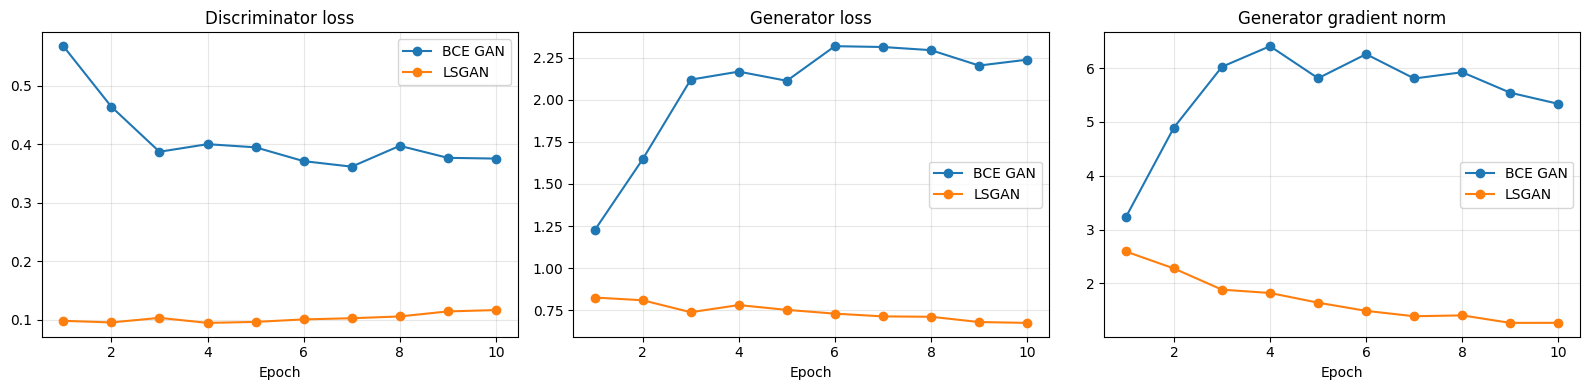

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, key, title in zip(
    axes,
    ["D_loss", "G_loss", "G_grad"],
    ["Discriminator loss", "Generator loss",
     "Generator gradient norm"]
):
    ax.plot(
        range(1, EPOCHS + 1),
        hist_bce[key],
        marker="o",
        label="BCE GAN"
    )
    ax.plot(
        range(1, EPOCHS + 1),
        hist_ls[key],
        marker="o",
        label="LSGAN"
    )

    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

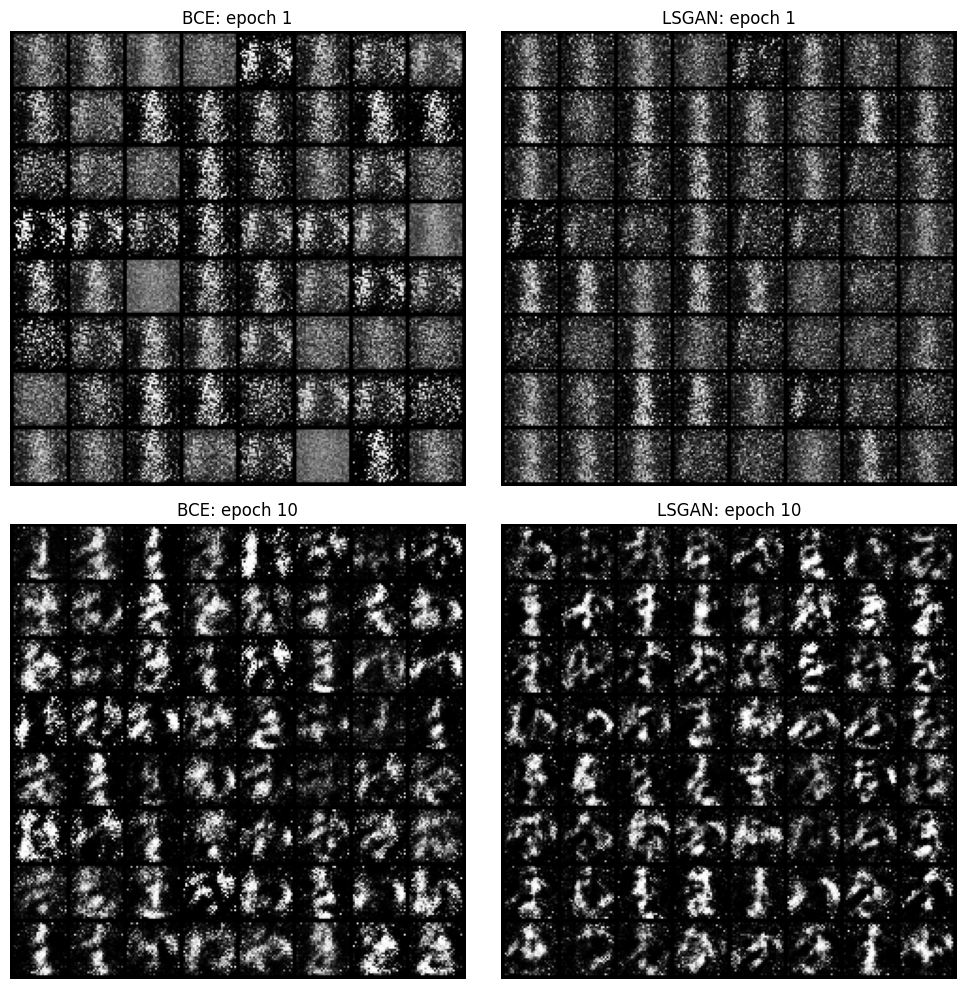

In [7]:
def show_samples(images, title, ax):
    grid = make_grid(
        (images[:64] + 1) / 2,
        nrow=8,
        padding=2
    )

    ax.imshow(grid.permute(1, 2, 0).numpy())
    ax.set_title(title)
    ax.axis("off")


fig, axes = plt.subplots(2, 2, figsize=(10, 10))

show_samples(
    images_bce[0],
    "BCE: epoch 1",
    axes[0, 0]
)

show_samples(
    images_ls[0],
    "LSGAN: epoch 1",
    axes[0, 1]
)

show_samples(
    images_bce[-1],
    f"BCE: epoch {EPOCHS}",
    axes[1, 0]
)

show_samples(
    images_ls[-1],
    f"LSGAN: epoch {EPOCHS}",
    axes[1, 1]
)

plt.tight_layout()
plt.show()

In [8]:
print(f"{'Measure':<26} {'BCE GAN':>12} {'LSGAN':>12}")
print("-" * 52)

for label, key in [
    ("Final discriminator loss", "D_loss"),
    ("Final generator loss", "G_loss"),
    ("Final generator gradient", "G_grad"),
]:
    print(
        f"{label:<26} "
        f"{hist_bce[key][-1]:>12.4f} "
        f"{hist_ls[key][-1]:>12.4f}"
    )

Measure                         BCE GAN        LSGAN
----------------------------------------------------
Final discriminator loss         0.3753       0.1167
Final generator loss             2.2390       0.6744
Final generator gradient         5.3354       1.2652
